# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement battery-management-system algorithms.

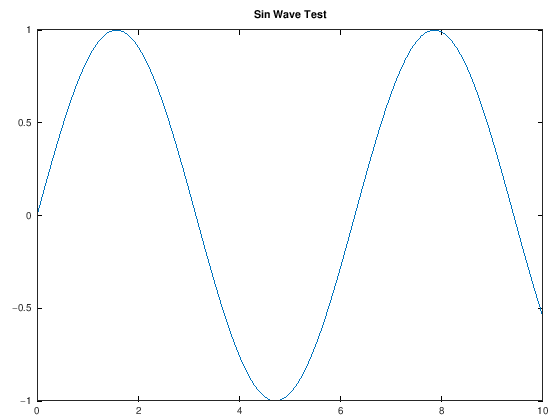

In [1]:
% Set the toolkit to gnuplot
graphics_toolkit('gnuplot')

% Force plots to be inline
set(0, 'defaultfigurevisible', 'off');

% Test plot
x = 0:0.1:10;
y = sin(x);
plot(x, y);
title('Sin Wave Test');

In [2]:
whos


Variables visible from the current scope:

variables in scope: top scope

  Attr   Name        Size                     Bytes  Class
  ====   ====        ====                     =====  ===== 
         x           1x101                       24  double
         y           1x101                      808  double

Total is 202 elements using 832 bytes



In [3]:
% 1. Load the data (skipping the first 8 lines of headers in your CSV)
raw_data = dlmread('cell_18ah_discharge.csv', ',', 11, 0);

% 2. Initialize an empty structure (This prevents the "empty structure array" error)
data = struct();

% 3. Assign the columns to the structure fields
% Column 1: Time(S), Column 2: Cur(A), Column 3: Vol(V)
data.time = raw_data(:, 1);
data.current = raw_data(:, 2);
data.voltage = raw_data(:, 3);
% data.step = raw_data(:, 4);
% data.disAh = raw_data(:, 5);
% data.chgAh = raw_data(:, 6);

% 4. Save to the MAT file
save('cell_18ah_discharge.mat', 'data');

In [4]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% This loads the OCV Test Script data from storage for a 25 degC test
% load E2_OCV_P25.mat
load cell_18ah_discharge.mat

In [5]:
% The variable "OCVData" has been loaded by the previous input box. Place 
% your cursor in this input code cell and depress < shift >< enter >

whos

Variables visible from the current scope:

variables in scope: top scope

  Attr   Name          Size                     Bytes  Class
  ====   ====          ====                     =====  ===== 
         data          1x1                      94992  struct
         raw_data   3958x3                      94992  double
         x             1x101                       24  double
         y             1x101                      808  double

Total is 12077 elements using 190816 bytes



### Visualizing data
There is an enormous amount of data stored from these four cell tests. One good way to visualize the data is via plotting. For example:

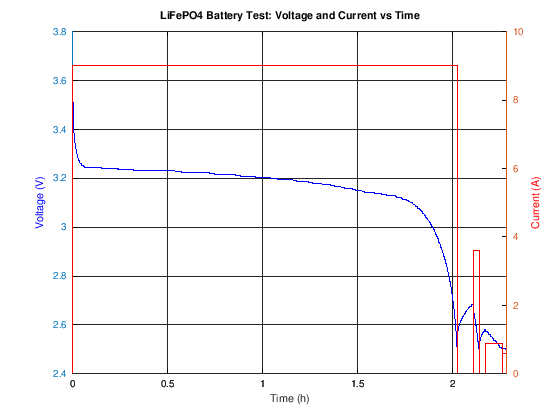

In [25]:
% 4. Plot using plotyy to create dual Y-axes
% plotyy(X1, Y1, X2, Y2)
[ax, h1, h2] = plotyy(data.time/3600, data.voltage, data.time/3600, data.current);

% 5. Customize the line styles (Optional but makes it look better)
set(h1, 'linewidth', 2, 'color', 'b'); % Voltage line (Blue)
set(h2, 'linewidth', 2, 'color', 'r'); % Current line (Red)

% 6. Add labels and title
xlabel('Time (h)', 'fontsize', 12);
ylabel(ax(1), 'Voltage (V)', 'fontsize', 12, 'color', 'b');
ylabel(ax(2), 'Current (A)', 'fontsize', 12, 'color', 'r');
title('LiFePO4 Battery Test: Voltage and Current vs Time', 'fontsize', 14);

% 7. Add grid and legend
grid on;
% legend([h1, h2], {'Voltage (V)', 'Current (A)'}, 'location', 'northeast');

### Finding coulombic efficiency
The data provided for use with this notebook are all measured at 25<sup>o</sup>C. We can use these data to find the coulombic efficiency of the cell at this temperature, as discussed in the lesson.

In [24]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute
% 1. Open the file for reading
fid = fopen('cell_18ah_discharge.csv', 'r');

% Variables to store our extracted capacities
totDisAh = 0;
totChgAh = 0;

% 2. Loop through the file line by line
while ~feof(fid)
    % Read the current line
    line = fgetl(fid);

    % 1. split the line by ,
    columns = strsplit(line, ',');

    % 2. check if the second column (index 1) matches D-CC
    if length(columns) > 1 && strcmp(columns{2}, 'D-CC')
        totDisAh = totDisAh + str2double(columns{3});
    end
    
    % Check if we reached the main data (so we can stop reading)
    if strncmp(line, 'Time(S)', 7)
        break; 
    end
end
% 5. Close the file (important to free up system resources!)
fclose(fid);
fid = fopen('cell_18ah_dither_vmin.csv', 'r');
% 2. Loop through the file line by line
while ~feof(fid)
    % Read the current line
    line = fgetl(fid);

    % 1. split the line by ,
    columns = strsplit(line, ',');

    % 2. check if the second column (index 1) matches D-CC
    if length(columns) > 1 && strcmp(columns{2}, 'D-CC')
        totDisAh = totDisAh + str2double(columns{3});
    end

    % 2. check if the second column (index 1) matches C-CV
    if length(columns) > 1 && strcmp(columns{2}, 'C-CV')
        totChgAh = totChgAh + str2double(columns{3});
    end
    
    % Check if we reached the main data (so we can stop reading)
    if strncmp(line, 'Time(S)', 7)
        break; 
    end
end
% 5. Close the file (important to free up system resources!)
fclose(fid);
fprintf("Total Ah discharged until dither vmin: %.3f Ah\n", totDisAh);

fid = fopen('cell_18ah_charge.csv', 'r');
% 2. Loop through the file line by line
while ~feof(fid)
    % Read the current line
    line = fgetl(fid);

    % 1. split the line by ,
    columns = strsplit(line, ',');

    % 2. check if the second column (index 1) matches C-CV
    if length(columns) > 1 && strcmp(columns{2}, 'C-CV')
        totChgAh = totChgAh + str2double(columns{3});
    end
    
    % Check if we reached the main data (so we can stop reading)
    if strncmp(line, 'Time(S)', 7)
        break; 
    end
end
% 5. Close the file (important to free up system resources!)
fclose(fid);
fid = fopen('cell_18ah_dither_vmax.csv', 'r');
% 2. Loop through the file line by line
while ~feof(fid)
    % Read the current line
    line = fgetl(fid);

    % 1. split the line by ,
    columns = strsplit(line, ',');

    % 2. check if the second column (index 1) matches D-CC
    if length(columns) > 1 && strcmp(columns{2}, 'D-CC')
        totDisAh = totDisAh + str2double(columns{3});
    end
    % 2. check if the second column (index 1) matches C-CV
    if length(columns) > 1 && strcmp(columns{2}, 'C-CV')
        totChgAh = totChgAh + str2double(columns{3});
    end
    
    % Check if we reached the main data (so we can stop reading)
    if strncmp(line, 'Time(S)', 7)
        break; 
    end
end
% 5. Close the file (important to free up system resources!)
fclose(fid);
% Display the results
fprintf('Capacity for ChgAh: %.3f Ah\n', totChgAh);
fprintf('Capacity for DisAh: %.3f Ah\n', totDisAh);
eta25 = totDisAh/totChgAh

Total Ah discharged until dither vmin: 18.510 Ah
Capacity for ChgAh: 18.707 Ah
Capacity for DisAh: 18.540 Ah
eta25 = 0.9911


### Finding total capacity
The total capacity (Q25) of this battery cell is equal to totDisAh of the Battery cell.

In [19]:
Q25 = totDisAh;

### Finding approximate OCV relationship at this temperature
The following code computes the approximate OCV versus SOC relationship using only the 25<sup>o</sup>C data set. The code is functionally the same as what you learned about in the lesson.

In [10]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute
SOC = 0:0.005:1; % output SOC points for this step

%identify first 
indC  = find(data.step == 3); % slow charge
IR1Ca = data.voltage(indC(1)) - data.voltage(indC(1)-1);
IR2Ca = data.voltage(indC(end)) - data.voltage(indC(end)+1);

indD  = find(data.step == 5); % slow discharge
IR1Da = data.voltage(indD(1)-1) - data.voltage(indD(1));
IR2Da = data.voltage(indD(end)+1) - data.voltage(indD(end));



In [11]:
disp(IR1Ca); disp(IR2Ca); %menampilkan voltage saat mulai dan akhir charging
disp(IR1Da); disp(IR2Da); %menampilkan voltage drop saat mulai dan akhir discharging


0.026000
6.0000e-03

0.021000
0.018000


In [12]:
IR1D = min(IR1Da,2*IR2Ca) %min(21mV, 2*6mV)
IR2D = min(IR2Da,2*IR1Ca) %min(18mV, 2*26mV)
IR1C = min(IR1Ca,2*IR2Da) %min(26mV, 2*18mV)
IR2C = min(IR2Ca,2*IR1Da) %min(6mV, 2*21mV)




IR1D = 0.012000

IR2D = 0.018000

IR1C = 0.026000

IR2C = 6.0000e-03


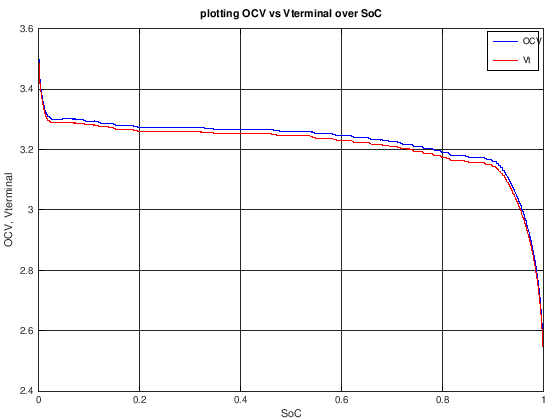

In [22]:
blend = (0:length(indD)-1)/(length(indD)-1);
IRblend = IR1D + (IR2D-IR1D)*blend(:);
disV = data.voltage(indD) + IRblend; % this is OCV voltage
disZ = 1 - data.disAh(indD)/Q25;     
disZ = disZ + (1 - disZ(1));
plot(1-disZ, disV, 'b');             % this is SoC
hold on;
xlabel('SoC')
ylabel('OCV') 
grid on
title('plotting OCV over SoC')

plot(1-disZ, data.voltage(indD), 'r');
%hold off;
xlabel('SoC')
ylabel('OCV, Vterminal') 
grid on
title('plotting OCV vs Vterminal over SoC')
legend("OCV", "Vt");
hold off;




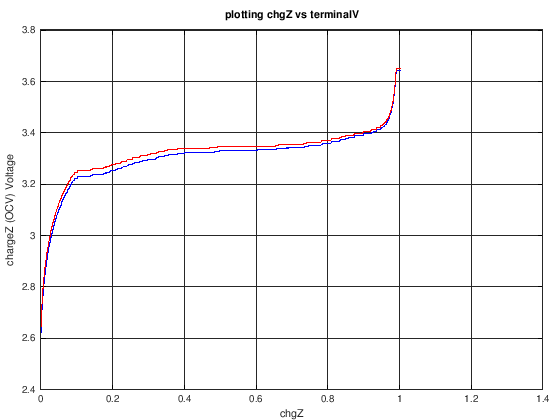

In [14]:
blend = (0:length(indC)-1)/(length(indC)-1);
IRblend = IR1C + (IR2C-IR1C)*blend(:);
chgV = data.voltage(indC) - IRblend;
chgZ = data.chgAh(indC)/Q25;
chgZ = chgZ - chgZ(1);

plot(chgZ, chgV, 'b');
hold on;
xlabel('chgZ')
ylabel('chargeVoltage') 
grid on
title('plotting chgZ vs chgV')

plot(chgZ, data.voltage(indC), 'r');
hold off;
xlabel('chgZ')
ylabel('chargeZ (OCV) Voltage') 
grid on
title('plotting chgZ vs terminalV')


    interp1 at line 242 column 11

    interp1 at line 242 column 11



0.069042













































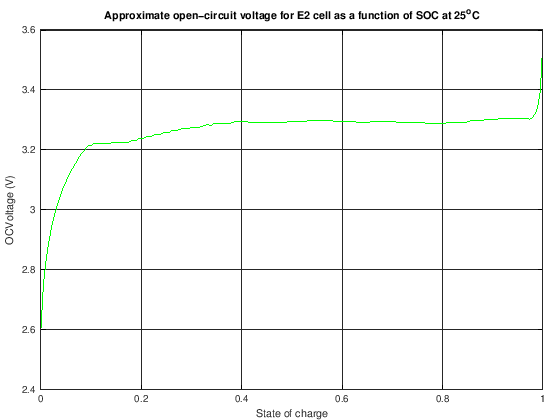

In [24]:
deltaV50 = interp1(chgZ,chgV,0.5) - interp1(disZ,disV,0.5); %find the voltage difference between charging 
                                                            %and discharging when the battery cell is exactly half-full.
disp(deltaV50);
ind = find(chgZ < 0.5);
vChg = chgV(ind) - chgZ(ind)*deltaV50;
zChg = chgZ(ind);

% plot(chgZ(ind), chgV(ind), 'r');
% hold on;
% xlabel('chgZ(ind)')
% ylabel('chargeVoltage(ind)') 
% grid on
% title('plotting chgZ(ind) vs chgV(ind)')

% plot(chgZ(ind), vChg, 'b');
% xlabel('chgZ(ind)')
% ylabel('vChg') 
% grid on
% title('plotting chgZ(ind) vs vChg')

ind = find(disZ > 0.5);
vDis_unflip = disV(ind) + (1 - disZ(ind))*deltaV50;
vDis = flipud(disV(ind) + (1 - disZ(ind))*deltaV50);
zDis = flipud(disZ(ind));

% plot(disZ(ind), disV(ind), 'r');
% hold on;
% xlabel('disZ(ind)')
% ylabel('disVoltage(ind)') 
% grid on
% title('plotting disZ(ind) vs disV(ind)')

% plot(disZ(ind), vDis_unflip, 'b');
% xlabel('disZ(ind)')
% ylabel('vDis_unflip') 
% grid on
% title('plotting disZ(ind) vs vDis_unflip')

rawocv = interp1([zChg; zDis],[vChg; vDis],SOC,'linear','extrap');
% At this point, the pair {SOC,rawocv} form a lookup table for the approximate OCV versus SOC relationship
% We can plot this relationship:
plot(SOC,rawocv, 'g')                
xlabel('State of charge')
ylabel('OCVoltage (V)') 
grid on
title('Approximate open-circuit voltage for E2 cell as a function of SOC at 25^oC')


In [16]:
% tidak dilakukan karena test data nya hanya satu, dengan asumsi temperature di 25*C
% % Compile voltages and temperatures into arrays rather than a structure
% Vraw = []; temps = [];
% for k = 1: numtemps,
%     if filedata(k).temp > 0,
%         Vraw = [Vraw; filedata(k).rawocv]; %#ok <AGROW >
%         temps = [temps;filedata(k).temp]; %#ok <AGROW >
%     end
% end
% % Perform least - squares fit of model to data
% X = [ ones(size(temps)), temps] \ Vraw;
% model.OCV0 = X(1,:);
% model.OCVrel = X(2,:);
% model.SOC = SOC;

### Table lookup
The relationship for OCV versus SOC is not yet final since we have processed only one temperature at this point. However, we can still use the computations performed to date in order to find a table-lookup approximate value of OCV as a function of SOC. 

In [17]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

testSOC = 0; % Replace "0.30" with whatever value of SOC for which you desire to know OCV
OCV = interp1(SOC,rawocv,testSOC)
testSOC = 1.0; % Replace "0.30" with whatever value of SOC for which you desire to know OCV
OCV = interp1(SOC,rawocv,testSOC)





OCV = 2.5970


OCV = 3.5650
